In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress

def make_path_exist(filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 23
    plt.rcParams["axes.labelsize"] = 30
    plt.rcParams["legend.fontsize"] = 21

    # plt.rcParams["font.size"] = 18
    # plt.rcParams["axes.labelsize"] = 24
    # plt.rcParams["legend.fontsize"] = 12

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [2]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [45]:
L_vals = [2000]
a_c = 0.75
a_vals = sorted(list(set([0.7535, 0.7555, 0.7575, 0.7595, 0.7615] + [0.757, 0.7572, 0.7574, 0.7576, 0.7578, 0.7579] + [0.75425, 0.75625, 0.758, 0.7581, 0.7582,  0.75825, 0.7583,  0.76025, 0.76225])))
a_vals = [0.7535, 0.7555, 0.757, 0.7572, 0.7574, 0.7575, 0.7576, 0.7578, 0.7579, 0.758, 0.7582, 0.7595, 0.7615]


N_val = 4

time_prefact = 5

num_initial_conds = 1700
num_init_conds_offset = 0

time_step = 1

cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "../data"
second_data_parent_folder = "/Volumes/ExternalData/s_diff_per_time_v2/"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/s_diff_per_time_v2/"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/s_diff_per_time_v2/"      
        second_data_parent_folder = "../data/s_diff_per_time_v2/"
else:
    data_parent_folder = local_data_parent_folder

# If first time

In [4]:


collected_sdiffs = {}
collected_sdiff_stds = {}

counts = []
for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    for a_val in a_vals:
        print(f"L_val: {L_val} | a: {a_val}")
        a_val_name = f"{a_val}".replace(".", "p")

        current_sdiff = []
        c = 0
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"N{N_val}/a{a_val_name}/IC1/L{L_val}/N{N_val}_a{a_val_name}_IC1_L{L_val}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
                
            try:
                df = pd.read_csv(sample_filepath_name)
                # 2026-09 files (get_sdiff_data_severalL*.jl): t = 0, time_step, ..., T_f are the true times.
                # Keep the first T_f // time_step rows (t = 0 ... T_f - time_step) so every later cell
                # sees the same array length and row i <-> t = i * time_step, as before.
                n_keep = T_f // time_step
                if not np.allclose(df.t.values[:n_keep], np.arange(n_keep) * time_step):
                    raise ValueError(f"unexpected t column in {sample_filepath_name}")
                current_sdiff.append(df.s_diff.values[:n_keep])
                c +=1
            except Exception as e:
                print(e)
                print(sample_filepath_name)
        counts.append(c)
        current_sdiff = np.array(current_sdiff)
        collected_sdiffs[L_val][a_val] = np.mean(current_sdiff.T, axis=1)
        collected_sdiff_stds[L_val][a_val] = np.std(current_sdiff.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")
        second_pickle_path = os.path.join(second_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")
                                                                
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_sdiffs[L_val][a_val], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_sdiff_stds[L_val][a_val], f)

        try:
            dir_path = os.path.dirname(second_pickle_path)
            os.makedirs(dir_path, exist_ok=True)
            with open(second_pickle_path + "mean.pickle", "wb") as f:
                pickle.dump(collected_sdiffs[L_val][a_val], f)
            with open(second_pickle_path + "stds.pickle", "wb") as f:
                pickle.dump(collected_sdiff_stds[L_val][a_val], f)
        except Exception as E:
            print(E)
print(min(counts))

L_val: 2000
L_val: 2000 | a: 0.7535
L_val: 2000 | a: 0.7555
L_val: 2000 | a: 0.757
L_val: 2000 | a: 0.7572
L_val: 2000 | a: 0.7574
L_val: 2000 | a: 0.7575
L_val: 2000 | a: 0.7576
L_val: 2000 | a: 0.7578
L_val: 2000 | a: 0.7579
L_val: 2000 | a: 0.758
L_val: 2000 | a: 0.7582
L_val: 2000 | a: 0.7595
L_val: 2000 | a: 0.7615
1700


## If you have already processed and saved the data as pickled

In [5]:

collected_sdiffs = {}
collected_sdiff_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        try:
            pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

        except:
            pickle_path = os.path.join(second_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

L_val: 2000


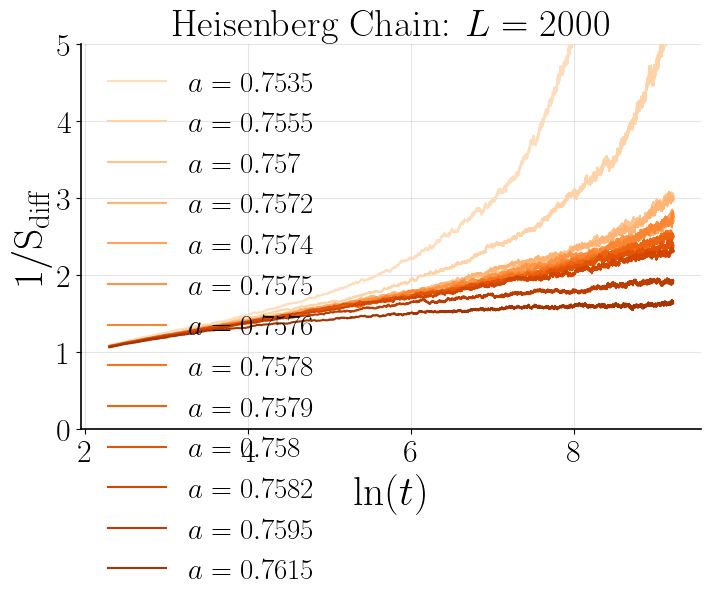

In [8]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    extra_prefact = 1
    if L == 512:
        extra_prefact = 2
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        time_vals = [i * time_step for i in range(0, L*time_prefact * extra_prefact// time_step)][:]
        data_to_plot = collected_sdiffs[L][a_val]
        plt.plot(
            np.log(time_vals[10:len(data_to_plot)]), 
            1/data_to_plot[10:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Heisenberg Chain: $L = {L}$")
plt.xlabel(r"$\ln(t)$")
plt.ylabel(r"$1/\mathrm{S_{diff}}$")
plt.legend()
plt.ylim(0., 5)

plt.show()


In [17]:
a_vals

[0.7535,
 0.7555,
 0.757,
 0.7572,
 0.7574,
 0.7575,
 0.7576,
 0.7578,
 0.7579,
 0.758,
 0.7582,
 0.7595,
 0.7615]

alpha = 0.693864803838126


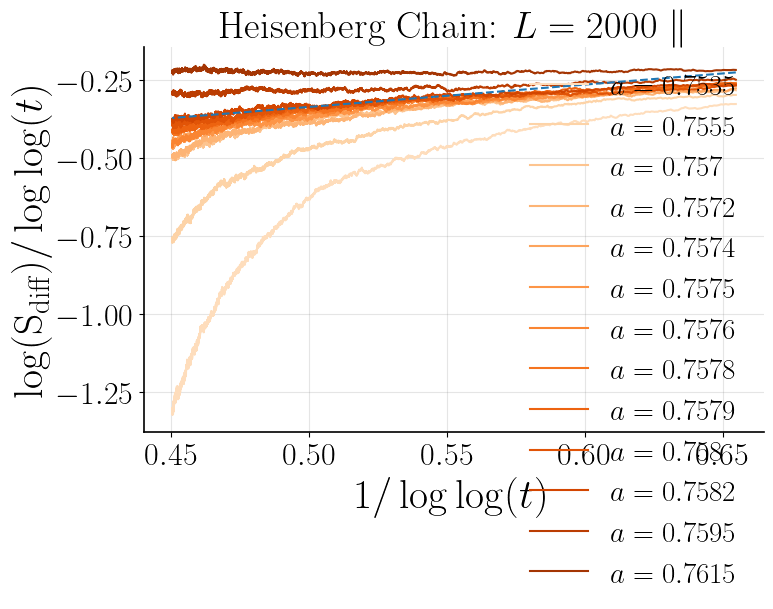

In [51]:
plt.figure(figsize=(8,5))

skip_int = 100
a_c = 0.7582

for j, L in enumerate(L_vals):
    if L == 512:
        extra_prefact = 2
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        data_to_plot = np.log(collected_sdiffs[L][a_val])[skip_int:]
        time_vals = [i * time_step for i in range(0, round(L*time_prefact / time_step))][skip_int:len(data_to_plot)+skip_int]
        log_log_time_vals = np.log(np.log(np.array(time_vals)))
        plt.plot(
            1/log_log_time_vals, 
            data_to_plot/log_log_time_vals, 
            label = fr"$a = {round(a_val, ndigits=7)}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        
    Y = np.log(collected_sdiffs[L][a_c])[skip_int:]
    X = 1/np.log(np.log(np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))][skip_int:len(Y)+skip_int])))
    m,b = np.polyfit(X, Y*X, 1)
    plt.plot(X, m * X + b, linestyle="--")
    print(f"alpha = {-b}")
    
# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Heisenberg Chain: $L = {L}$ $\|$")
plt.xlabel(r"$1/\log \log(t)$")
plt.ylabel(r"$\log(\mathrm{S_{diff}})/\log \log(t)$")
plt.legend()
# plt.ylim(-1, -0)

plt.show()


In [ ]:
# Running log-exponent  alpha_eff(T) = ln[S(T/b)/S(T)] / ln[ln T / ln(T/b)]
# (constant = alpha for S ~ (ln t)^-alpha; BVH predict alpha -> 1).
# Fixed 2026-09 (review 4.3.5): the old version compared S(T/b - 1) with S(T - 1) (off by one),
# hit data[-1] (the LAST element) at T = 0, and plotted against a `time_vals` left over
# from another cell. Here collected_sdiffs[L][a][k] is S_diff at t = k * time_step.
b = 2
alpha = 1.0
cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

plt.figure(figsize=(9,6))
for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        S = np.asarray(collected_sdiffs[L][a_val])
        k_small = np.arange(1, len(S))                  # index of T/b
        k_big = k_small * b                             # index of T
        keep = (k_big < len(S)) & (np.log(k_small * time_step) >= 1.0)   # ln(T/b) >= 1: denominator well away from 0
        k_small, k_big = k_small[keep], k_big[keep]
        T = k_big * time_step
        alpha_eff = np.log(S[k_small] / S[k_big]) / np.log(np.log(T) / np.log(T / b))
        plt.plot(
            np.log(1 / T),
            alpha_eff,
            label = fr"$a = {a_val}$",
            c=c
            )

plt.axhline(alpha, c = 'k', label=fr"$\alpha = {alpha}$", linestyle ="--")
plt.xlabel(r"$\ln(1/t)$")
plt.ylabel(r"$\alpha_{\rm eff}=\frac{\ln[S(t/b)/S(t)]}{\ln[\ln t/\ln(t/b)]}$")
plt.legend(fontsize=10)
plt.xlim((-9.5, -1))
plt.tight_layout()
file_path = f"figs/time_random/alpha{str(alpha).replace('.', 'p')}/spinchain_alpha_eff.png"
make_path_exist(file_path)
# plt.savefig(file_path)
plt.show()

Beta 0.2632


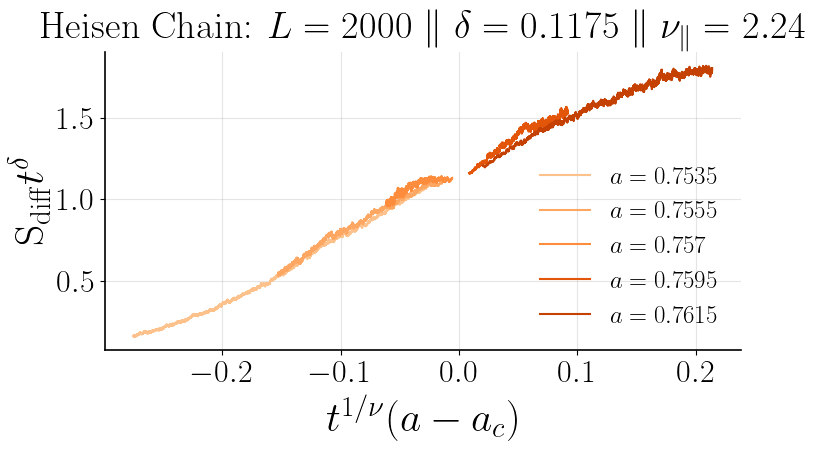

In [15]:
delta_guess = 0.1175 # pm 0.003
guess_nu_par = 2.24 # pm 0.1
a_c = 0.758 # pm 0.0002
a_vals = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]

cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}

print(f"Beta {delta_guess * guess_nu_par}")
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    plt.figure(figsize=(8,5))
    for i, a_val in enumerate(a_vals):
        if a_val == a_c or a_val == 0.7579:
            continue
        c = cmaps[L](i+3)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50:], 
            (orig_data * time_vals ** delta_guess)[50:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        # plt.axvline(finite_sized_time**(1/guess_nu_par)*(a_val-a_c),ymin=0.5, ymax=0.9, c=c)
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Heisen Chain: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.xlabel(r"$t^{1/\nu}(a - a_c)$")
    plt.ylabel(r"$\mathrm{S_{diff}}t^\delta$")
    plt.legend()
    # plt.xlim(-0.2, 0.2)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    file_path=f"figs/time_random/spin_chain/spinchain_determining_nu_par.png"
    make_path_exist(file_path)
    # plt.savefig(file_path)
    plt.show()

> Looks like 
- $a_c \approx 0.758 \pm 0.0003$
- $\nu \approx 2.24 \pm 0.15$ 
- $\beta \approx 0.230 \pm 0.016$

Beta 0.23
figs/time_random/spin_chain/spinchain_determining_nu_par.png


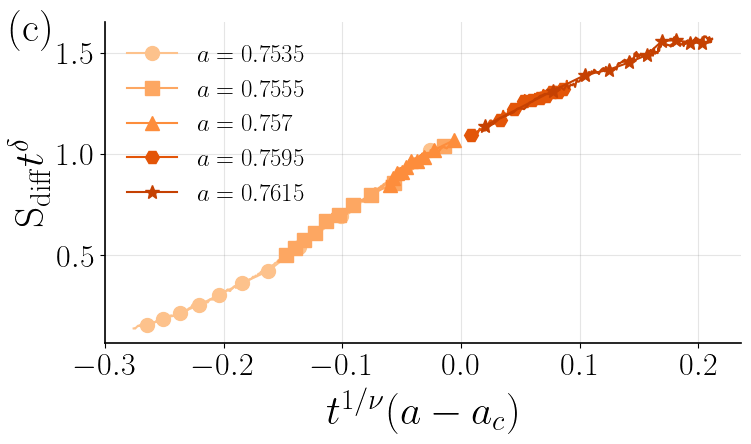

In [16]:
guess_nu_par = 2.24 # pm 0.1
a_c = 0.758027 # pm 0.0002
beta = 0.23
delta_guess = beta/guess_nu_par # pm 0.003
a_vals = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]

plt.rcParams["legend.fontsize"] = 18
cmaps = {2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}
markers = ['o', 's', '^', 'D', 'H', '*', 'v', '<', '>',  'd', 'p', 'h', 'X', 'P', '+', 'x', '|', '_', ]

print(f"Beta {delta_guess * guess_nu_par}")
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    fig = plt.figure(figsize=(8,5))
    for i, a_val in enumerate(a_vals):
        if abs(a_val - a_c) <= 0.001:
            continue
        c = cmaps[L](i+3)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50::50], 
            (orig_data * time_vals ** delta_guess)[50::50], 
            # label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50::1000], 
            (orig_data * time_vals ** delta_guess)[50::1000], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            markersize=10,
            marker = markers[i],
            # capsize=3,
            c=c
            )
        # plt.axvline(finite_sized_time**(1/guess_nu_par)*(a_val-a_c),ymin=0.5, ymax=0.9, c=c)
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Heisen Chain: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.043, 0.855, "(c)", fontsize=plt.rcParams["axes.labelsize"],
        transform=fig.transFigure)
    plt.xlabel(r"$t^{1/\nu}(a - a_c)$")
    plt.ylabel(r"$\mathrm{S_{diff}}t^{\delta}$")
    plt.legend()
    # plt.xlim(-0.2, 0.2)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    file_path=f"figs/time_random/spin_chain/spinchain_determining_nu_par.png"
    make_path_exist(file_path)
    plt.savefig(file_path)
    print(file_path)
    plt.show()

Beta 0.23
figs/time_random/spin_chain/spinchain_determining_nu_par.png


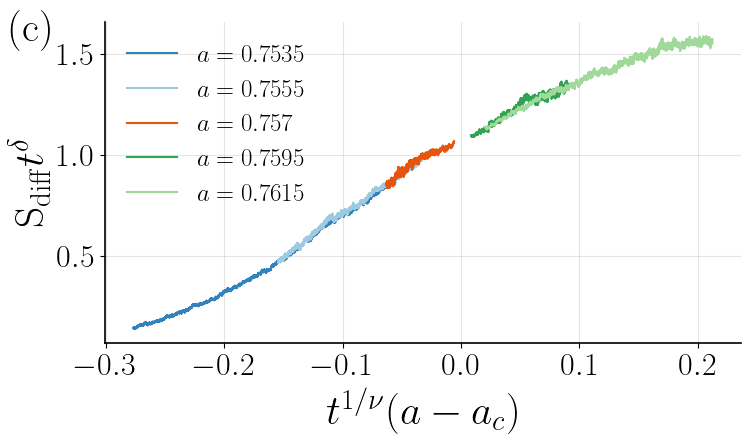

In [17]:
guess_nu_par = 2.24 # pm 0.1
a_c = 0.758027 # pm 0.0002
beta = 0.23
delta_guess = beta/guess_nu_par # pm 0.003
a_vals = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]

plt.rcParams["legend.fontsize"] = 18
cmaps = {2000: plt.colormaps.get_cmap("tab20c").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5), 1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5)}
# markers = ['o', 's', '^', 'D', 'H', '*', 'v', '<', '>',  'd', 'p', 'h', 'X', 'P', '+', 'x', '|', '_', ]

print(f"Beta {delta_guess * guess_nu_par}")
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    fig = plt.figure(figsize=(8,5))
    for i, a_val in enumerate(a_vals):
        if abs(a_val - a_c) <= 0.001:
            continue
        c = cmaps[L](i)
        time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(a_val - a_c))[50:], 
            (orig_data * time_vals ** delta_guess)[50:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        # plt.axvline(finite_sized_time**(1/guess_nu_par)*(a_val-a_c),ymin=0.5, ymax=0.9, c=c)
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Heisen Chain: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.043, 0.855, "(c)", fontsize=plt.rcParams["axes.labelsize"],
        transform=fig.transFigure)
    plt.xlabel(r"$t^{1/\nu}(a - a_c)$")
    plt.ylabel(r"$\mathrm{S_{diff}}t^{\delta}$")
    plt.legend()
    # plt.xlim(-0.2, 0.2)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    file_path=f"figs/time_random/spin_chain/spinchain_determining_nu_par.png"
    make_path_exist(file_path)
    plt.savefig(file_path)
    print(file_path)
    plt.show()

figs/time_random/delta0p1075/spinchain_determining_ac_delta_nu_par.png


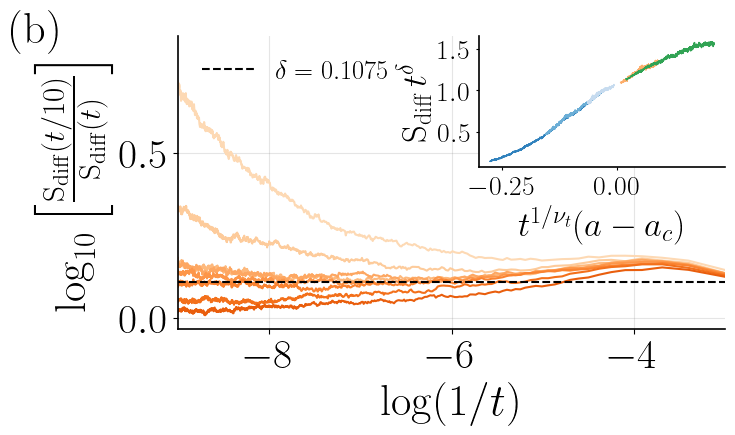

In [18]:
b = 10
delta_guess = 0.1075
a_vals = [0.7535, 0.7555, 0.757, 0.7572, 0.7574, 0.758, 0.7595, 0.7615]

guess_nu_par = 2.24
a_c = 0.758027
beta = 0.23
delta_guess_c = beta / guess_nu_par

plt.rcParams["font.size"] = 30
plt.rcParams["axes.labelsize"] = 32
plt.rcParams["legend.fontsize"] = 19
cmaps = {
    2000: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) * 2),
    512:  plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5),
    1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5),
}
cmaps_c = {
    2000: plt.colormaps.get_cmap("tab20c").resampled(len(a_vals) + 5),
    512:  plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5),
    1024: plt.colormaps.get_cmap("Reds").resampled(len(a_vals) + 5),
}

fig, ax = plt.subplots(figsize=(8, 5))

# --- Inset axes (plot c content) ---
ax_inset = ax.inset_axes([0.55, 0.55, 0.45, 0.45])

# --- Main plot (b) ---
for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i + 3)
        data_to_plot = collected_sdiffs[L][a_val]
        t_vals = [(i) * time_step for i in range((len(data_to_plot) // b)) if (i) * time_step]
        time_vals = [i * b * time_step for i in t_vals]
        data_to_plot_numerator = np.array([data_to_plot[(t // (b * time_step))] for t in time_vals])
        data_to_plot_denominator = np.array([data_to_plot[t // time_step] for t in time_vals])
        data_to_plot_ratio = log_b(
            data_to_plot_numerator[:len(data_to_plot_denominator)] / data_to_plot_denominator, 10
        )

        ax.plot(
            np.log((1 / np.array(time_vals))[1:]),
            data_to_plot_ratio[1:],
            c=c
        )

ax.axhline(delta_guess, c='k', label=fr"$\delta = {delta_guess}$", linestyle="--")
ax.text(0.05, 0.855, "(b)", transform=fig.transFigure, fontsize=plt.rcParams["axes.labelsize"])
ax.set_xlabel(r"$\log(1/t)$")
ax.set_ylabel(r"$\log_{10}\left[\frac{\mathrm{S_{diff}}(t/10)}{\mathrm{S_{diff}}(t)}\right]$")
ax.legend(loc="upper left")
ax.set_xlim((-9, -3))

# --- Inset (plot c content) ---
a_vals_c = [0.7535, 0.7555, 0.757, 0.758, 0.7595, 0.7615]
for j, L in enumerate(L_vals):
    if L != max(L_vals):
        continue
    for i, a_val in enumerate(a_vals_c):
        if abs(a_val - a_c) <= 0.001:
            continue
        c = cmaps_c[L](i)
        time_vals = np.array([i * time_step for i in range(0, L * time_prefact // time_step)])
        orig_data = collected_sdiffs[L][a_val][0:len(time_vals)]
        ax_inset.plot(
            (time_vals ** (1 / guess_nu_par) * (a_val - a_c))[50:],
            (orig_data * time_vals ** delta_guess_c)[50:],
            c=c,
            lw=0.9
        )

# --- Inset formatting ---
ax_inset.grid(False)
ax_inset.set_xlabel(r"$t^{1/\nu_t}(a - a_c)$", fontsize=25)
ax_inset.set_ylabel(r"$\mathrm{S_{diff}}\,t^{\delta}$", fontsize=25)
ax_inset.tick_params(labelbottom=True, labelleft=True, length=2, labelsize=20)
ax_inset.set_facecolor(fig.get_facecolor())

fig.tight_layout()

file_path = f"figs/time_random/delta{str(delta_guess).replace('.', 'p')}/spinchain_determining_ac_delta_nu_par.png"
make_path_exist(file_path)
plt.savefig(file_path)
print(file_path)
plt.show()

## BVH infinite-noise test: $1/A = a + B\ln t$ (review 4.3.4, added 2026-09)
The infinite-noise form of Barghathi, Vojta and Hoyos is linear in $\ln t$, so it needs no
extrapolation, and $a/B=\ln t_0$ absorbs the microscopic time scale. The table compares it
with a power law fitted over the same window. The $\chi^2_\nu$ values ignore the
correlations between times, so compare the two columns with each other only. The plot
shows the local slope $d(1/A)/d\ln t$ over a factor 2 in $t$: constant (= B) at the BVH
critical point, rising on the inactive side and falling toward 0 on the active side.

In [ ]:
# A = S_diff. Uses collected_sdiffs / collected_sdiff_stds from the loading cells;
# row i is t = i * time_step.
fit_tmin, fit_tmax = 50, 5000          # a window inside the data (and ideally before finite-size effects)
bvh_keys = [(L_val, a) for L_val in L_vals for a in a_vals]
bvh_t    = {k: np.arange(len(collected_sdiffs[k[0]][k[1]])) * time_step for k in bvh_keys}
bvh_A    = {k: np.asarray(collected_sdiffs[k[0]][k[1]]) for k in bvh_keys}
bvh_sem  = {k: np.asarray(collected_sdiff_stds[k[0]][k[1]]) / np.sqrt(num_initial_conds) for k in bvh_keys}
rows = []
for key in bvh_keys:
    t = np.asarray(bvh_t[key], float); A = np.asarray(bvh_A[key], float); sA = np.asarray(bvh_sem[key], float)
    m = (t >= fit_tmin) & (t <= fit_tmax) & (A > 0) & (sA > 0)
    x = np.log(t[m])
    y, sy = 1 / A[m], sA[m] / A[m]**2                               # BVH: 1/A, error sigma_A / A^2
    (B, a), cov = np.polyfit(x, y, 1, w=1/sy, cov="unscaled")
    chi2_bvh = np.sum(((y - (a + B*x)) / sy)**2) / (m.sum() - 2)
    (slope, c), _ = np.polyfit(x, np.log(A[m]), 1, w=A[m]/sA[m], cov="unscaled")   # power law, same window
    chi2_pow = np.sum(((np.log(A[m]) - (c + slope*x)) / (sA[m]/A[m]))**2) / (m.sum() - 2)
    rows.append({"key": key, "B": B, "B_err": np.sqrt(cov[0, 0]), "ln t0 = a/B": a / B, "chi2r BVH": chi2_bvh,
                 "delta (power law)": -slope, "chi2r power": chi2_pow, "points": int(m.sum())})
print("chi2r ignores correlations between times: compare the two columns, do not read them absolutely")
display(pd.DataFrame(rows).round(4))

fig, ax = plt.subplots(figsize=(8, 5))                    # local slope over a factor 2 in t
for key in bvh_keys:
    t = np.asarray(bvh_t[key], float); A = np.asarray(bvh_A[key], float)
    ok = (t > 0) & (A > 0); t, A = t[ok], A[ok]; T = t[t / 2 >= t[0]]
    ax.plot(np.log(T), (1/A[np.searchsorted(t, T)] - np.interp(np.log(T/2), np.log(t), 1/A)) / np.log(2), label=f"{key[-1]}")
ax.set_xlabel(r"$\ln t$"); ax.set_ylabel(r"$d(1/A)/d\ln t$"); ax.legend(fontsize=8); plt.show()